# Atmospheric Sounding with Tropical Cyclone Potential Intensity

This notebook plots atmospheric soundings using **sounderpy** and calculates **tropical cyclone potential intensity** using **tcpyPI**.

## Features:
- Plots full atmospheric sounding with Skew-T diagram, hodograph, and thermodynamic parameters
- Calculates TC potential intensity (VMAX, PMIN) using Emanuel's PI theory
- Annotates PI values on the sounding plot
- Shows SST marker and SST parcel path (with virtual temperature)
- Compares ocean thermodynamic potential vs. atmospheric parcels

In [1]:
# Check and install sounderpy
try:
    import sounderpy
except ImportError:
    !pip install sounderpy

# Check and install tcpypi
try:
    import tcpypi
except ImportError:
    !pip install tcpypi

# Check and install metpy
try:
    import metpy
except ImportError:
    !pip install metpy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.2/326.2 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.3/14.3 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 90.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 91.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.1/65.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.8/145.8 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 70.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.8/87.8 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.3

In [2]:
# Import required libraries
import warnings
warnings.filterwarnings('ignore')

# Enable inline plotting for Jupyter
%matplotlib inline

import numpy as np
import sounderpy as spy
from tcpyPI import pi
from metpy.calc import (mixing_ratio_from_relative_humidity,
                        relative_humidity_from_dewpoint,
                        moist_lapse,
                        saturation_mixing_ratio,
                        virtual_temperature)
from metpy.units import units
import matplotlib.pyplot as plt
from datetime import datetime

print('Libraries loaded successfully!')


## ---------------------------------- SOUNDERPY ----------------------------------- ##
##          Vertical Profile Data Retrieval and Analysis Tool For Python            ##
##                   v3.1.0 | October 2025 | (C) Kyle J Gillett                     ##
##                 Docs: https://kylejgillett.github.io/sounderpy/                  ##
## --------------------- THANK YOU FOR USING THIS PACKAGE! ------------------------ ##

Libraries loaded successfully!


## Input Sounding Data

Define your atmospheric sounding data here. All arrays must have the same length.

**Required variables:**
- `pressure`: Pressure levels (hPa)
- `height`: Height above ground (meters)
- `temperature`: Temperature (°C)
- `dewpoint`: Dewpoint temperature (°C)
- `u_wind`: Eastward wind component (m/s)
- `v_wind`: Northward wind component (m/s)
- `SST`: Sea surface temperature (°C)
- `MSLP`: Mean sea level pressure (hPa)

In [3]:
# Example tropical sounding data
pressure = np.array([1000, 975, 950, 925, 900, 875, 850, 825, 800, 775, 750, 725, 700,
                     650, 600, 550, 500, 450, 400, 350, 300, 250, 200, 150, 100, 50])

height = np.array([10, 250, 500, 750, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000,
                   3500, 4200, 4950, 5800, 6750, 7800, 9050, 10500, 12200, 14300, 17000, 20500, 26000])

temperature = np.array([28.0, 26.5, 25.0, 23.5, 22.0, 20.5, 19.0, 17.5, 16.0, 14.5, 13.0, 11.5, 10.0,
                        7.0, 4.0, 0.5, -3.5, -8.0, -13.0, -19.0, -26.0, -34.0, -44.0, -56.0, -71.0, -85.0])
# T experiments:
# temperature = np.array([38.0, 36.5, 15.0, 23.5, 22.0, 20.5, 19.0, 17.5, 16.0, 14.5, 13.0, 11.5, 10.0,
#                         7.0, 4.0, 0.5, -3.5, -8.0, -13.0, -19.0, -26.0, -34.0, -44.0, -56.0, -71.0, -85.0])
# temperature = np.array([18.0, 16.5, 25.0, 23.5, 22.0, 20.5, 19.0, 17.5, 16.0, 14.5, 13.0, 11.5, 10.0,
#                         7.0, 4.0, 0.5, -3.5, -8.0, -13.0, -19.0, -26.0, -34.0, -44.0, -56.0, -71.0, -85.0])
# temperature = temperature + 15

dewpoint = np.array([24.0, 23.5, 23.0, 21.5, 20.0, 18.5, 17.0, 15.0, 13.0, 11.0, 9.0, 7.0, 5.0,
                     1.0, -3.0, -8.0, -12.0, -18.0, -25.0, -35.0, -45.0, -55.0, -65.0, -75.0, -85.0, -95.0])
# Td experiments:
# dewpoint = np.array([0.0, 0.0, 23.0, 21.5, 20.0, 18.5, 17.0, 15.0, 13.0, 11.0, 9.0, 7.0, 5.0,
#                      1.0, -3.0, -8.0, -12.0, -18.0, -25.0, -35.0, -45.0, -55.0, -65.0, -75.0, -85.0, -95.0])
# zeros = np.zeros_like(dewpoint)
# dewpoint = temperature

u_wind = np.array([2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0, 8.5,
                   9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5, 14.0, 14.5, 15.0])

v_wind = np.array([1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0,
                   7.5, 8.0, 8.5, 9.0, 9.5, 10.0, 10.5, 11.0, 11.5, 12.0, 12.5, 13.0, 13.5])

# Sea surface temperature and pressure
SST = 29.0   # °C
MSLP = 1010.0  # hPa

# Site information
site_name = 'TROPICAL'
site_location = 'EXAMPLE'
site_lat = 15.0
site_lon = -60.0
site_elevation = 10

print(f'Loaded sounding data with {len(pressure)} levels')
print(f'Surface: {pressure[0]} hPa, T = {temperature[0]}°C, Td = {dewpoint[0]}°C')
print(f'SST: {SST}°C, MSLP: {MSLP} hPa')

Loaded sounding data with 26 levels
Surface: 1000 hPa, T = 28.0°C, Td = 24.0°C
SST: 29.0°C, MSLP: 1010.0 hPa


## Prepare Data for Sounderpy

Sounderpy requires data with MetPy units attached.

In [4]:
# Attach MetPy units
pressure_units = pressure * units.hPa
height_units = height * units.meter
temperature_units = temperature * units.degC
dewpoint_units = dewpoint * units.degC
u_wind_units = u_wind * units('m/s')
v_wind_units = v_wind * units('m/s')

# Create sounderpy clean_data dictionary
clean_data = {
    'p': pressure_units,
    'z': height_units,
    'T': temperature_units,
    'Td': dewpoint_units,
    'u': u_wind_units,
    'v': v_wind_units,
    'site_info': {
        'site-name': site_name,
        'site-lctn': site_location,
        'site-latlon': [site_lat, site_lon],
        'site-elv': site_elevation,
        'source': 'USER INPUT DATA',
        'model': 'no-model',
        'fcst-hour': 'no-fcst-hour',
        'run-time': [datetime.now().strftime('%Y'), datetime.now().strftime('%m'),
                     datetime.now().strftime('%d'), datetime.now().strftime('%H')],
        'valid-time': [datetime.now().strftime('%Y'), datetime.now().strftime('%m'),
                       datetime.now().strftime('%d'), datetime.now().strftime('%H')]
    },
    'titles': {
        'top_title': f'{site_name} SOUNDING',
        'left_title': f'{site_name} | {site_location}',
        'right_title': datetime.now().strftime('%Y-%m-%d %H:%M UTC')
    }
}

print('Data prepared for sounderpy')

Data prepared for sounderpy


## Calculate Tropical Cyclone Potential Intensity

Using the tcpyPI package to calculate maximum potential intensity based on Emanuel's PI theory.

In [5]:
# Calculate mixing ratio for PI calculation
T_with_units = temperature * units.degC
Td_with_units = dewpoint * units.degC
P_with_units = pressure * units.hPa

rh = relative_humidity_from_dewpoint(T_with_units, Td_with_units)
mixing_ratio = mixing_ratio_from_relative_humidity(P_with_units, T_with_units, rh)
mixing_ratio_gkg = mixing_ratio.magnitude * 1000  # Convert to g/kg

# Calculate PI using tcpyPI
VMAX, PMIN, IFL, TO, LNB = pi(SST, MSLP, pressure, temperature, mixing_ratio_gkg)

# Convert to knots and determine Saffir-Simpson category
VMAX_knots = VMAX * 1.944

if VMAX_knots < 64:
    category = 'Tropical Storm'
elif VMAX_knots < 83:
    category = 'Category 1'
elif VMAX_knots < 96:
    category = 'Category 2'
elif VMAX_knots < 113:
    category = 'Category 3'
elif VMAX_knots < 137:
    category = 'Category 4'
else:
    category = 'Category 5'

print('\n=== Tropical Cyclone Potential Intensity ===')
print(f'Maximum Potential Wind Speed (VMAX): {VMAX:.1f} m/s ({VMAX_knots:.1f} knots)')
print(f'Minimum Central Pressure (PMIN): {PMIN:.1f} hPa')
print(f'Outflow Temperature (TO): {TO:.1f} K ({TO-273.15:.1f}°C)')
print(f'Level of Neutral Buoyancy (LNB): {LNB:.1f} hPa')
print(f'Saffir-Simpson Category: {category}')
print(f'Sea Surface Temperature: {SST}°C')


=== Tropical Cyclone Potential Intensity ===
Maximum Potential Wind Speed (VMAX): 52.1 m/s (101.3 knots)
Minimum Central Pressure (PMIN): 969.5 hPa
Outflow Temperature (TO): 211.4 K (-61.8°C)
Level of Neutral Buoyancy (LNB): 130.8 hPa
Saffir-Simpson Category: Category 3
Sea Surface Temperature: 29.0°C


## Calculate SST Parcel Path with Virtual Temperature

Calculate the moist adiabat from the SST using virtual temperature to show the ocean's thermodynamic potential.

In [6]:
# Calculate moist adiabat from SST
SST_degC = SST * units.degC
pressure_levels = np.array([1000, 975, 950, 925, 900, 875, 850, 800, 750, 700, 650, 600, 550, 500,
                            450, 400, 350, 300, 250, 200, 150, 100]) * units.hPa

# Temperature along moist adiabat
sst_adiabat_temps = moist_lapse(pressure_levels, SST_degC, reference_pressure=1000*units.hPa)

# Saturation mixing ratio along the adiabat
sst_sat_mixr = saturation_mixing_ratio(pressure_levels, sst_adiabat_temps)

# Virtual temperature along the adiabat (for proper buoyancy)
sst_virtual_temps = virtual_temperature(sst_adiabat_temps, sst_sat_mixr)

SST_Tv = sst_virtual_temps[0].magnitude  # Virtual temperature at surface

print(f'\nSST: {SST}°C')
print(f'SST Virtual Temperature: {SST_Tv:.1f}°C')
print(f'Virtual temperature boost: +{SST_Tv - SST:.1f}°C (due to saturation)')


SST: 29.0°C
SST Virtual Temperature: 33.6°C
Virtual temperature boost: +4.6°C (due to saturation)


## Plot Sounding with PI Annotation

Create the full sounding plot with:
- Atmospheric temperature and dewpoint profiles
- Atmospheric parcels (SB, MU, ML CAPE) using virtual temperature
- SST parcel path (magenta) using virtual temperature
- SST markers showing actual and virtual temperature
- PI calculation results annotated on the plot

> SOUNDING PLOTTER FUNCTION
  ---------------------------------


    > COMPLETE --------
    > RUNTIME: 00:00:04


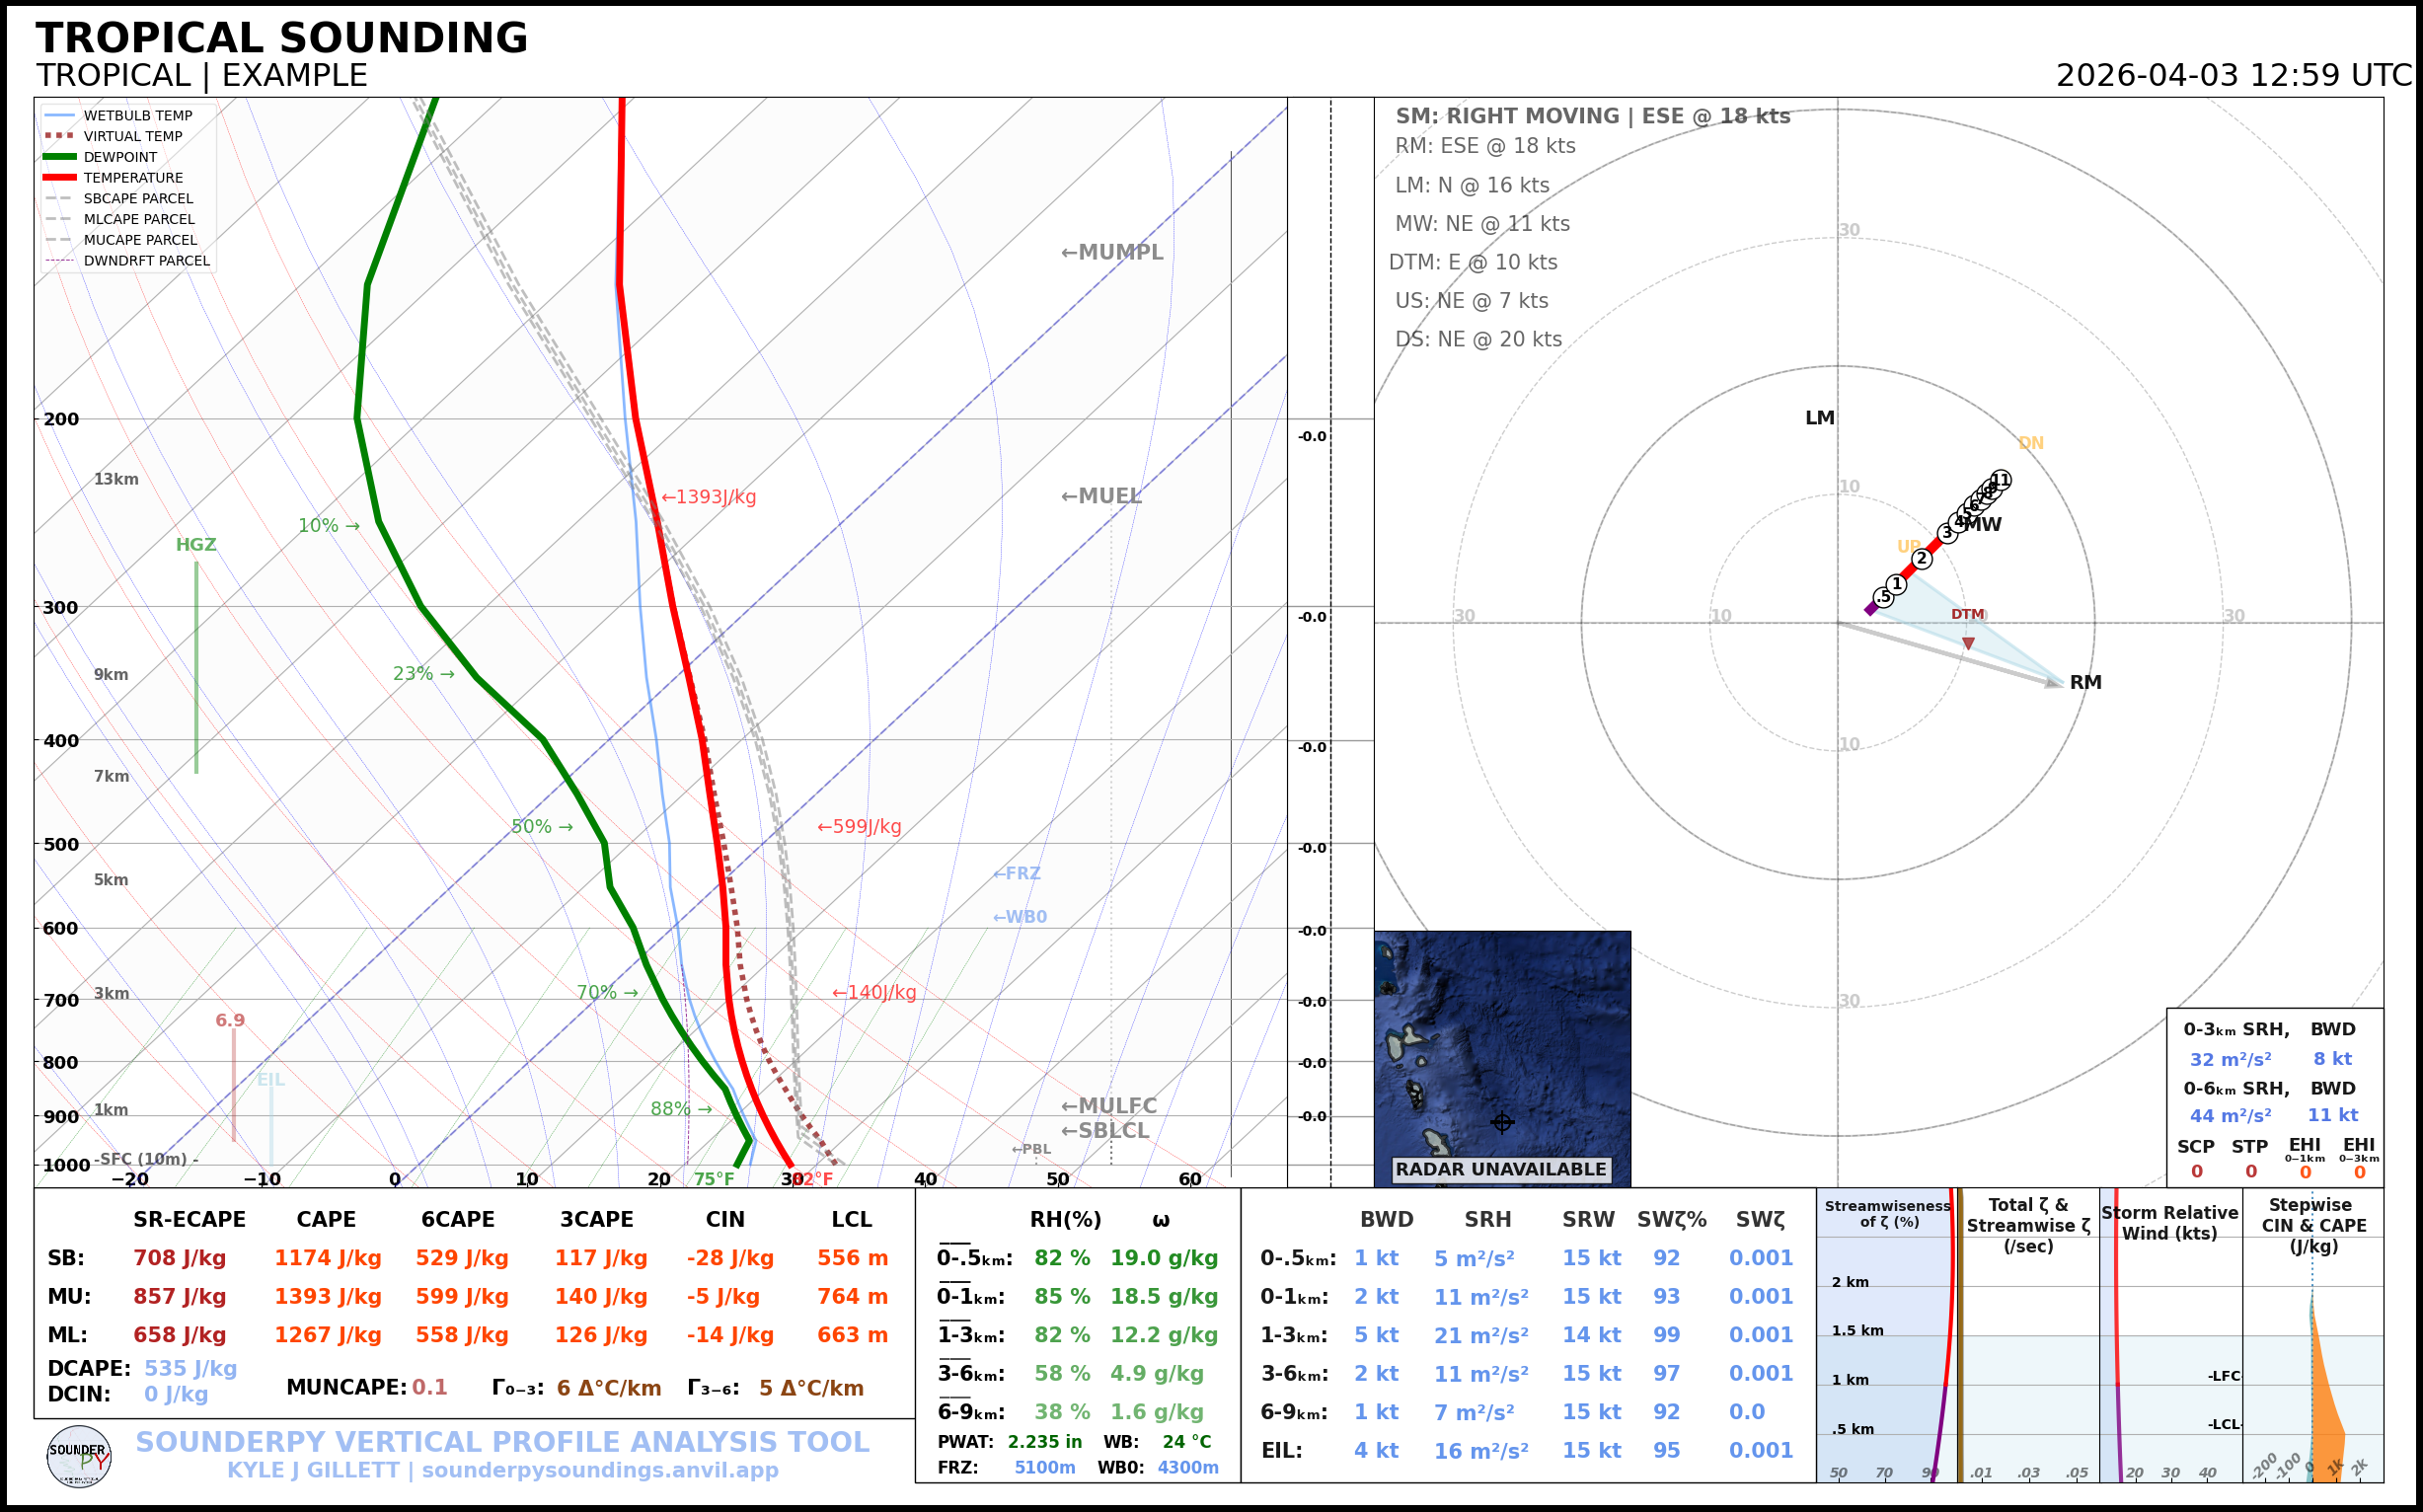

In [7]:
# Build sounding - this creates the figure
spy.build_sounding(clean_data, style='full', color_blind=False, dark_mode=False,
                   special_parcels='simple')


#### Make second version with special annotations for potential intensity + sea surface temperature that sounderpy can't do automatically:
1.   add sea surface temperature (SST) point + its virtual temperature (assumes the "air" at the SST is saturated)
2.   add annotation for each
3.   add moist adiabat buoyancy profile for parcel lifted from SST (magenta)
4.   add potential intensity calculated value annotation



In [8]:
# Sounderpy in google colab clears the figure axes after the plot displays, so this code is a workaround

# Plot sounding and IMMEDIATELY capture the figure reference
import matplotlib
matplotlib.use('Agg')  # Prevent auto-display in Colab
import matplotlib.pyplot as plt


plt.close('all')

# Build sounding - this creates the figure
spy.build_sounding(clean_data, style='full', color_blind=False, dark_mode=False,
                   special_parcels='simple')

# IMMEDIATELY capture the figure before Colab displays it
# Store it in a variable we can use in the next cell
saved_fig = plt.gcf()
saved_axes = saved_fig.get_axes()

print(f"Captured figure with {len(saved_axes)} axes")


> SOUNDING PLOTTER FUNCTION
  ---------------------------------


    > COMPLETE --------
    > RUNTIME: 00:00:03
Captured figure with 10 axes


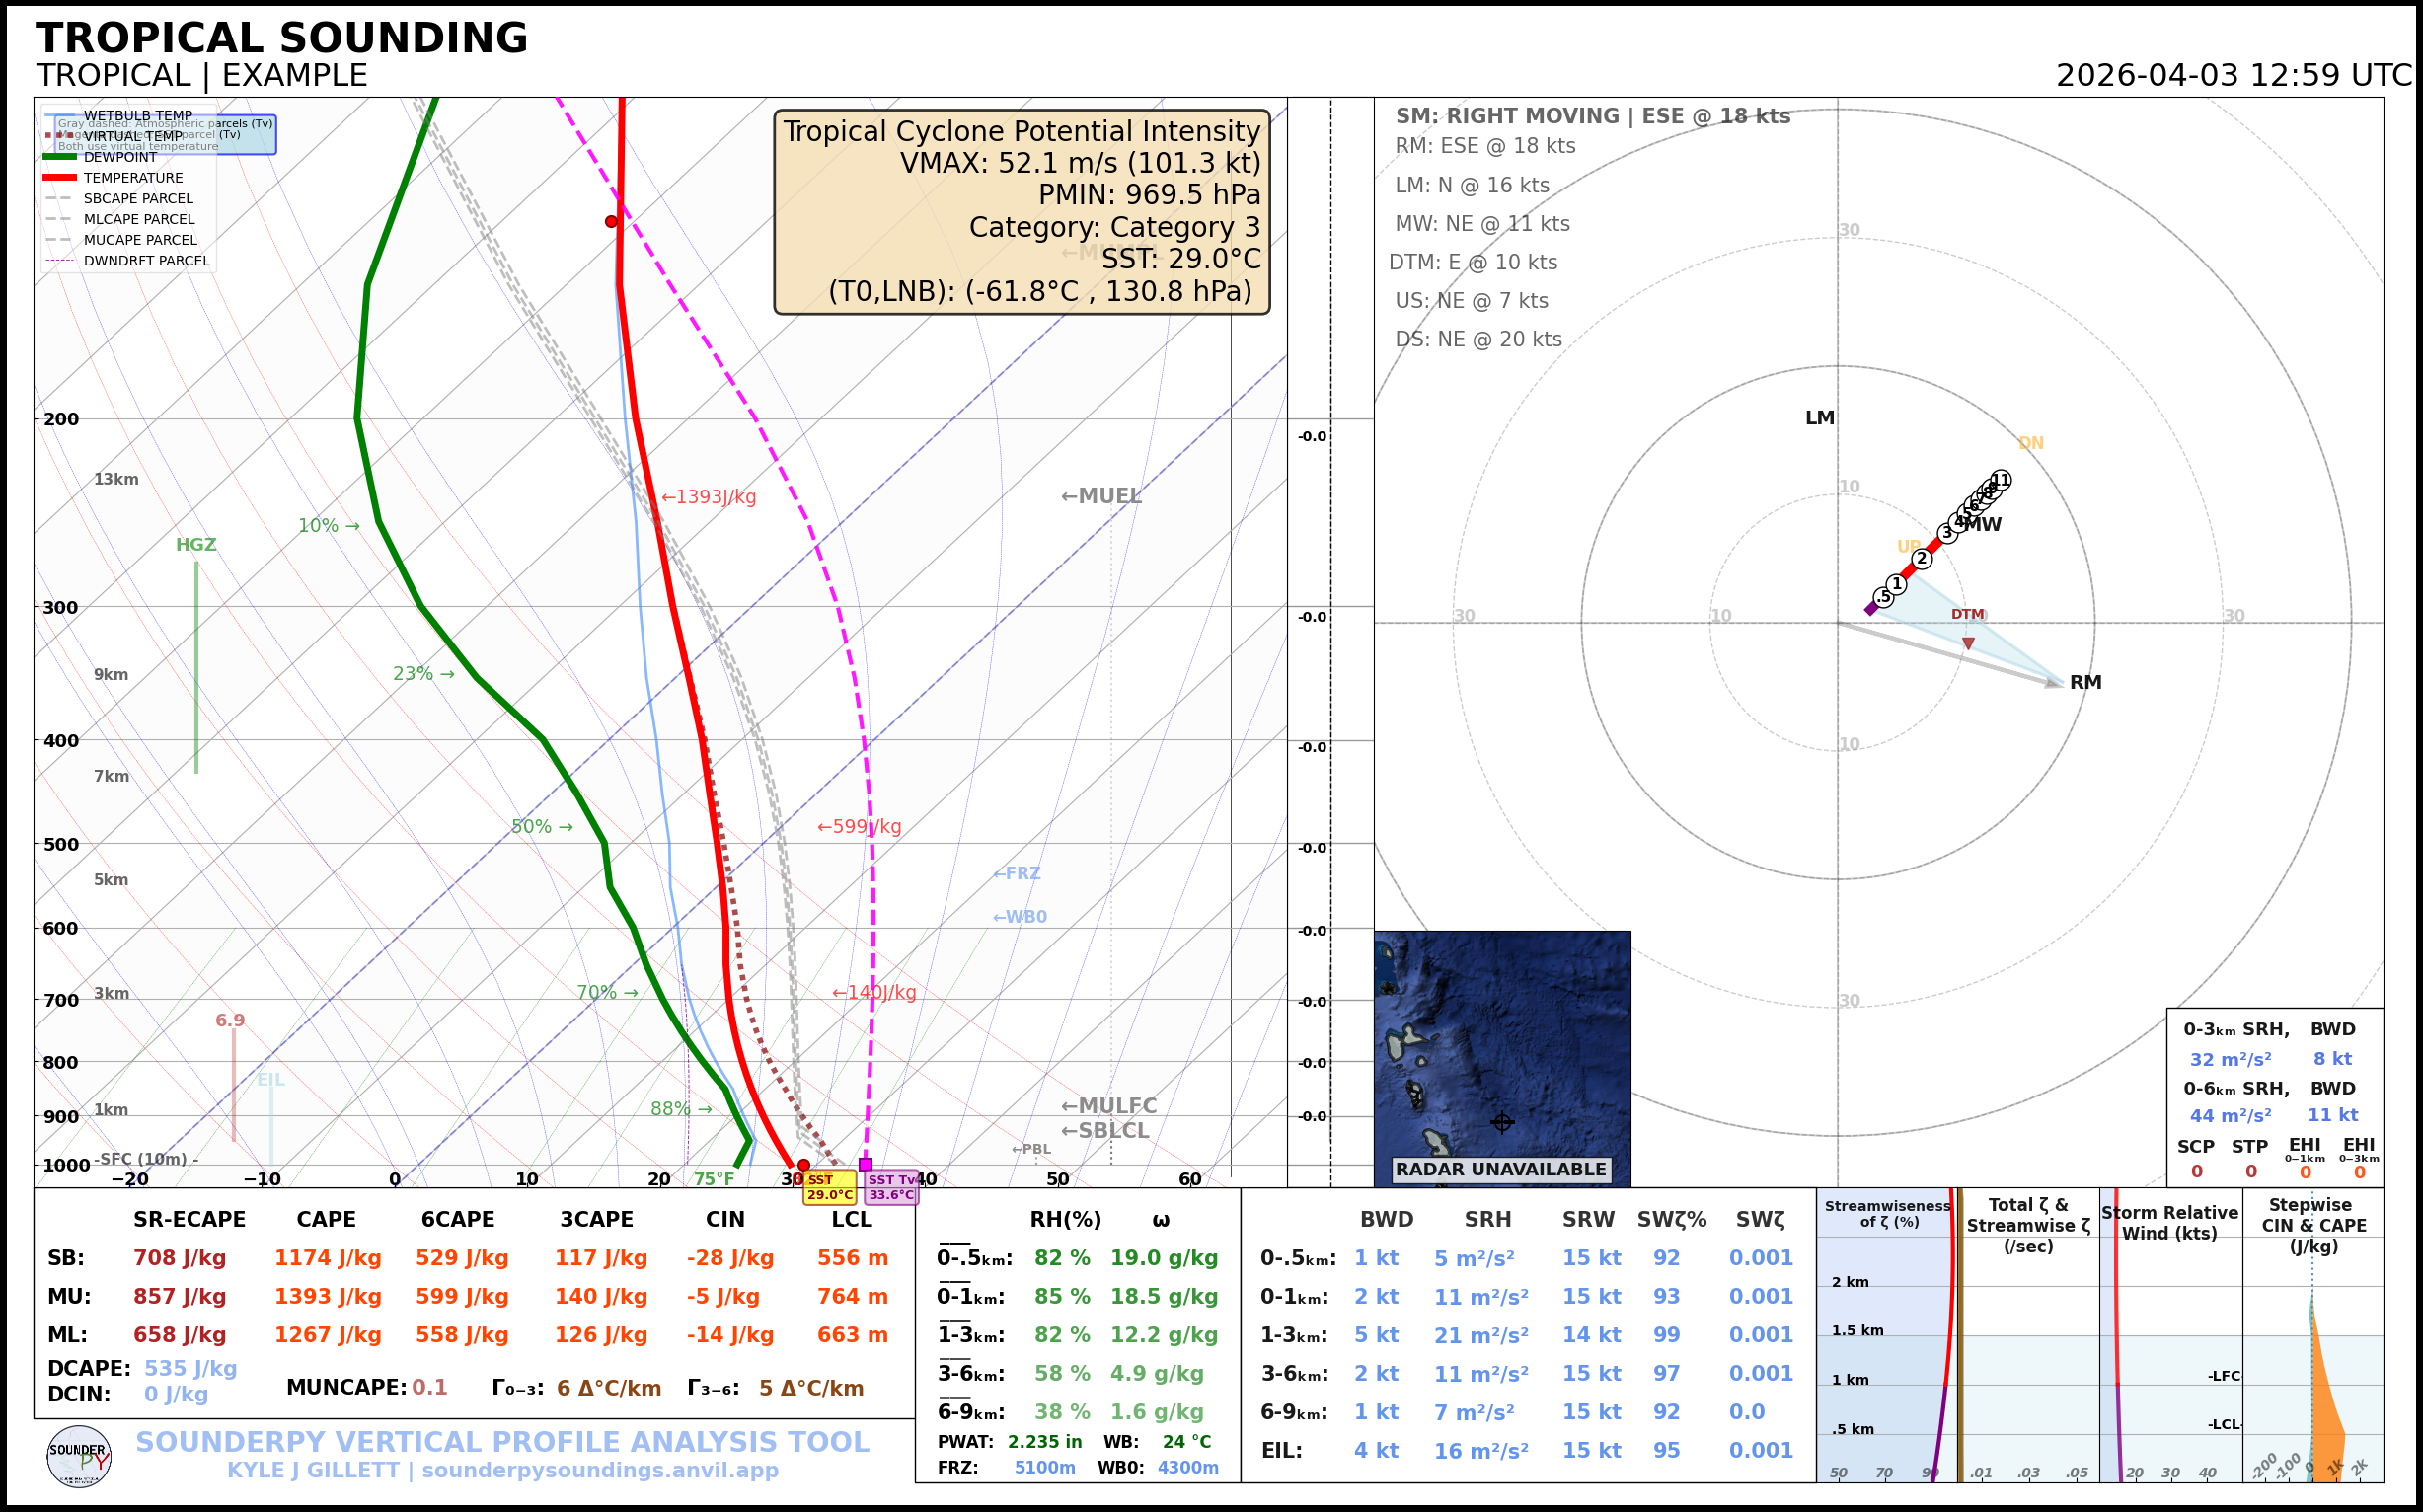


Sounding plot with annotations complete!


In [9]:
# Use the saved figure reference from the previous cell
current_fig = saved_fig
axes = saved_axes
skewt_ax = axes[0]

# Plot the SST moist adiabat using VIRTUAL TEMPERATURE (magenta dashed line)
skewt_ax.plot(sst_virtual_temps.magnitude, pressure_levels.magnitude,
              color='magenta', linewidth=3, linestyle='--',
              label=f'SST Parcel (Tv)', zorder=9, alpha=0.9)

# Add SST marker (red circle - actual temperature)
skewt_ax.plot(SST, 1000, marker='o', markersize=8, color='red',
              markeredgecolor='darkred', markeredgewidth=1.5,
              label=f'SST: {SST}°C', zorder=10)

# Add SST Virtual Temperature marker (magenta square - where parcel starts)
skewt_ax.plot(SST_Tv, 1000, marker='s', markersize=8, color='magenta',
              markeredgecolor='purple', markeredgewidth=1.5,
              label=f'SST Tv: {SST_Tv:.1f}°C', zorder=10)

# SST label below the x-axis (semi-transparent)
skewt_ax.text(SST + 1, 1020, f'SST\n{SST}°C',
              fontsize=9, fontweight='bold', color='darkred',
              verticalalignment='top',
              zorder=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow',
                       edgecolor='darkred', linewidth=1.5, alpha=0.6))

# SST Tv label below the x-axis (semi-transparent)
skewt_ax.text(SST_Tv + 1, 1020, f'SST Tv\n{SST_Tv:.1f}°C',
              fontsize=9, fontweight='bold', color='purple',
              verticalalignment='top',
              zorder=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='plum',
                       edgecolor='purple', linewidth=1.5, alpha=0.6))

# Add outflow (T0, LNB) marker
skewt_ax.plot(TO-273.15, LNB, marker='o', markersize=8, color='red',
              markeredgecolor='darkred', markeredgewidth=1.5,
              label=f'(T0,LNB): ({TO-273.15:.1f}°C , {LNB:.1f} hPa)', zorder=10)

# Add explanation annotation
explanation_text = (
    f'Gray dashed: Atmospheric parcels (Tv)\n'
    f'Magenta dashed: SST parcel (Tv)\n'
    f'Both use virtual temperature'
)

skewt_ax.text(0.02, 0.98, explanation_text,
              transform=skewt_ax.transAxes,
              fontsize=8,
              verticalalignment='top',
              horizontalalignment='left',
              bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.7,
                       edgecolor='blue', linewidth=1.5))

# Add PI annotation to the Skew-T axis (not the figure)
annotation_text = (
    f'Tropical Cyclone Potential Intensity\n'
    f'VMAX: {VMAX:.1f} m/s ({VMAX_knots:.1f} kt)\n'
    f'PMIN: {PMIN:.1f} hPa\n'
    f'Category: {category}\n'
    f'SST: {SST}°C\n'
    f'(T0,LNB): ({TO-273.15:.1f}°C , {LNB:.1f} hPa) '
)

# Position it in the top-right of the Skew-T axis
# Using axis coordinates (0-1 scale)
skewt_ax.text(0.98, 0.98, annotation_text,
              transform=skewt_ax.transAxes,  # Use axis coordinates
              fontsize=20,
              verticalalignment='top',
              horizontalalignment='right',
              bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8,
                       edgecolor='black', linewidth=2))


# Display the modified figure
display(current_fig)
print('\nSounding plot with annotations complete!')




## Understanding the Plot

### Key Elements:

1. **Solid Lines**:
   - Red: Environmental temperature profile
   - Green: Environmental dewpoint profile

2. **Gray Dashed Lines**: Atmospheric parcels (SB, MU, ML CAPE)
   - Calculated using virtual temperature for proper buoyancy
   - Show the actual atmospheric convective potential

3. **Magenta Dashed Line**: SST parcel path
   - Moist adiabat from the ocean surface (SST)
   - Uses virtual temperature (saturated parcel)
   - Shows the thermodynamic potential of the ocean

4. **Markers**:
   - Red circle: SST (actual ocean temperature)
   - Magenta square: SST virtual temperature (where magenta parcel starts)
   - The difference shows the buoyancy boost from moisture

5. **PI Annotation Box**: Shows calculated tropical cyclone potential intensity

### Physical Interpretation:

- The **SST parcel** (magenta) represents the maximum thermodynamic potential available from the ocean
- The **atmospheric parcels** (gray) show the actual atmospheric state
- The **virtual temperature** accounts for the buoyancy effect of water vapor
- Higher SST → warmer parcel → greater buoyancy → higher potential intensity
- The area between the parcel path and environmental temperature represents available energy (CAPE)